# DCGAN Multimodal — Generación de Nuevos Pokémon (64x64)

## Descripción de la Actividad
En este cuadernillo se implementa una **DCGAN (Deep Convolutional Generative Adversarial Network)** para trabajar con el **"Pokemon Image Dataset"**.

Cumpliendo con los requisitos del enunciado:
- **Red DCGAN pura:** Se utilizan exclusivamente capas convolucionales (`Conv2d` y `ConvTranspose2d`), eliminando cualquier arquitectura MLP/Lineal.
- **Dataset Multimodal:** El dataset original es multimodal, ya que contiene información visual (Imágenes de las generaciones 1 a 7) e información tabular (un archivo `pokemon.csv` con los tipos primarios, secundarios y líneas evolutivas). Para esta tarea, nos enfocaremos en la modalidad de imagen.
- **Generación de nuevos elementos:** El objetivo del modelo es aprender los patrones visuales y generar siluetas de **nuevos Pokémon** a partir de ruido aleatorio.
- **Restricción de tamaño:** Las imágenes originales tienen diferentes dimensiones, pero el `DataLoader` las procesará para tener un tamaño exacto de **64x64 píxeles en formato RGB (3 canales)**.

In [13]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils

# Configuración del dispositivo (GPU si está disponible)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo a utilizar: {device}")

Dispositivo a utilizar: cuda:0


### Celda 3 (Tipo: Código) - Carga del Dataset 

In [15]:
# ── RUTA A TU DATASET DE POKÉMON ──
# RECUERDA: La carpeta "PokemonDataset" debe contener una subcarpeta (ej. "imagenes") 
# y dentro de esa subcarpeta deben estar los archivos .jpg/.png
ruta_dataset = r'D:\2026\IA-2026-DATASETS\NUEVO_DATASET'

# Transformaciones: Redimensionar a 64x64, Recorte central, y Normalización RGB
transformaciones = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.RandomHorizontalFlip(p=0.5), # Aumento de datos (voltea los Pokémon para tener más variedad)
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

# Cargar dataset usando ImageFolder
dataset = dset.ImageFolder(root=ruta_dataset, transform=transformaciones)

# DataLoader configurado con un batch size adecuado para este volumen de datos
batch_size = 64
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"¡Éxito! Se cargaron {len(dataset)} imágenes de Pokémon listas para entrenar.")

¡Éxito! Se cargaron 809 imágenes de Pokémon listas para entrenar.


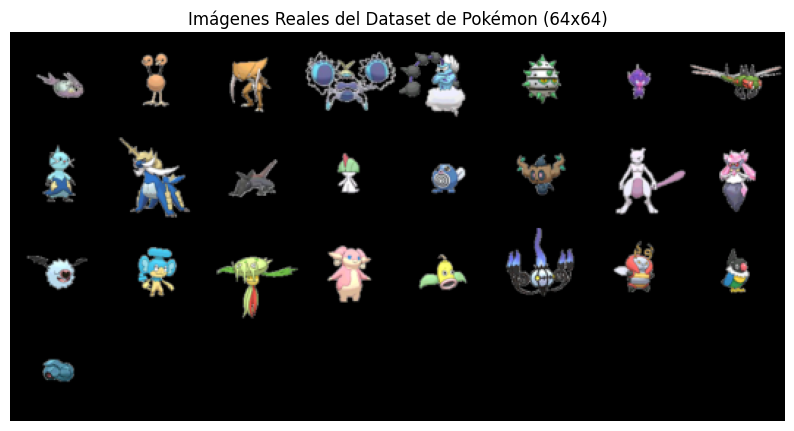

In [16]:
# Sacamos un lote de imágenes para ver cómo son los datos reales
lote_real = next(iter(dataloader))

plt.figure(figsize=(10,10))
plt.axis("off")
plt.title("Imágenes Reales del Dataset de Pokémon (64x64)")

# Mostramos una cuadrícula de 25 imágenes
cuadricula = vutils.make_grid(lote_real[0][:25], padding=2, normalize=True)
plt.imshow(np.transpose(cuadricula.cpu(), (1, 2, 0)))
plt.show()

### Celda 4 (Tipo: Markdown)
## Arquitectura DCGAN

A diferencia de una GAN tradicional (MLP), la DCGAN utiliza las siguientes reglas arquitectónicas:
1. Reemplazar cualquier agrupación (pooling) por convoluciones estriadas (stride) en el Discriminador y convoluciones transpuestas en el Generador.
2. Usar `BatchNorm` tanto en el Generador como en el Discriminador.
3. Eliminar capas densas (Fully Connected) para arquitecturas más profundas.
4. Usar `ReLU` y `Tanh` en el Generador.
5. Usar `LeakyReLU` en todas las capas del Discriminador.

In [17]:
nz = 100 # Tamaño del vector de ruido latente Z
nc = 3   # Número de canales (3 para imágenes a color RGB)
ngf = 64 # Tamaño de mapas de características del Generador

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            
            # Capa final que escupe 3 canales para formar el Pokémon a color
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

netG = Generator().to(device)

### Celda 6 (Tipo: Código) - El Discriminador Convolucional

In [18]:
ndf = 64 # Tamaño de mapas de características del Discriminador

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Recibe la imagen del Pokémon de 3 canales (nc=3)
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Evalúa si la imagen es un Pokémon real o falso
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

netD = Discriminator().to(device)

### Celda 7 (Tipo: Código) - Inicialización y Optimizadores

In [19]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG.apply(weights_init)
netD.apply(weights_init)

criterion = nn.BCELoss()

# Tasas de aprendizaje: El Discriminador aprende un poco más lento (0.0001)
# para darle ventaja al Generador, dado que el dataset tiene pocas imágenes (~800)
lr_G = 0.0002
lr_D = 0.0001
beta1 = 0.5

optimizerD = optim.Adam(netD.parameters(), lr=lr_D, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr_G, betas=(beta1, 0.999))

# Semilla de ruido fijo para ver cómo el modelo evoluciona dibujando lo mismo
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

### Celda 8 (Tipo: Código) - Bucle de Entrenamiento

In [20]:
# Como el dataset tiene solo ~800 imágenes, necesitamos muchas épocas
num_epochs = 200 
img_list = []
G_losses = []
D_losses = []

print("Iniciando el entrenamiento de la DCGAN...")
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        
        # -----------------------------------------
        # 1. Entrenar el Discriminador
        # -----------------------------------------
        netD.zero_grad()
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        
        # LABEL SMOOTHING: 0.9 para las reales (Evita sobreajuste del discriminador)
        label = torch.full((b_size,), 0.9, dtype=torch.float, device=device)
        
        output = netD(real_cpu)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()
        
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.0) # 0 para las imágenes falsas
        
        output = netD(fake.detach())
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        
        errD = errD_real + errD_fake
        optimizerD.step()

        # -----------------------------------------
        # 2. Entrenar el Generador
        # -----------------------------------------
        netG.zero_grad()
        label.fill_(1.0) # El generador quiere que el discriminador crea que son reales (1)
        output = netD(fake)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        # Guardar historial de pérdidas
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Imprimir progreso
        if i % 10 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(dataloader)}] '
                  f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} '
                  f'D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')

    # Al final de cada época, guardamos cómo se ven nuestras creaciones
    with torch.no_grad():
        fake = netG(fixed_noise).detach().cpu()
    img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

Iniciando el entrenamiento de la DCGAN...
[0/200][0/13] Loss_D: 1.6551 Loss_G: 2.5757 D(x): 0.4984 D(G(z)): 0.5125 / 0.0970
[0/200][10/13] Loss_D: 1.0308 Loss_G: 5.2256 D(x): 0.7761 D(G(z)): 0.3518 / 0.0085
[1/200][0/13] Loss_D: 0.8538 Loss_G: 5.9051 D(x): 0.8170 D(G(z)): 0.2701 / 0.0045
[1/200][10/13] Loss_D: 0.6868 Loss_G: 6.7492 D(x): 0.7646 D(G(z)): 0.1078 / 0.0016
[2/200][0/13] Loss_D: 0.5090 Loss_G: 7.6968 D(x): 0.8912 D(G(z)): 0.0782 / 0.0007
[2/200][10/13] Loss_D: 0.6215 Loss_G: 7.1865 D(x): 0.7836 D(G(z)): 0.1140 / 0.0009
[3/200][0/13] Loss_D: 0.6302 Loss_G: 7.4243 D(x): 0.9561 D(G(z)): 0.1200 / 0.0008
[3/200][10/13] Loss_D: 0.5293 Loss_G: 9.2849 D(x): 0.8776 D(G(z)): 0.0006 / 0.0001
[4/200][0/13] Loss_D: 0.4752 Loss_G: 13.5520 D(x): 0.8198 D(G(z)): 0.0004 / 0.0000
[4/200][10/13] Loss_D: 0.4878 Loss_G: 8.0339 D(x): 0.9486 D(G(z)): 0.0363 / 0.0004
[5/200][0/13] Loss_D: 0.8071 Loss_G: 6.0658 D(x): 0.5237 D(G(z)): 0.0057 / 0.0029
[5/200][10/13] Loss_D: 0.6927 Loss_G: 9.9079 D(x):

### Celda 9 (Tipo: Código) - Visualización de Resultados

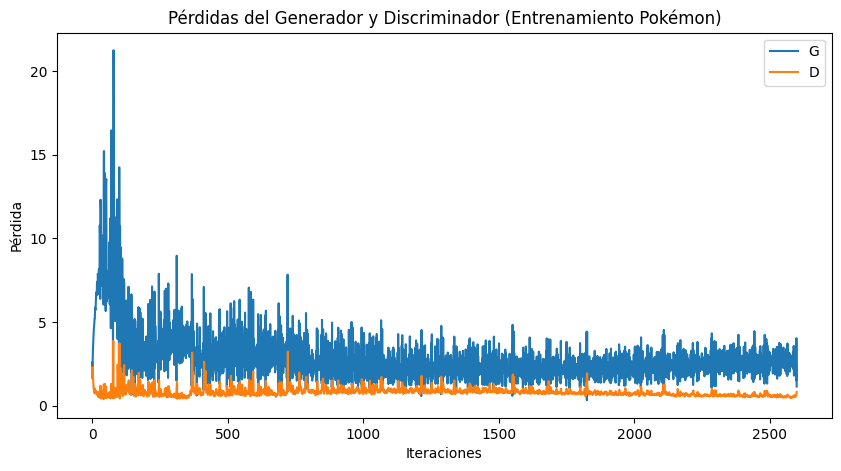

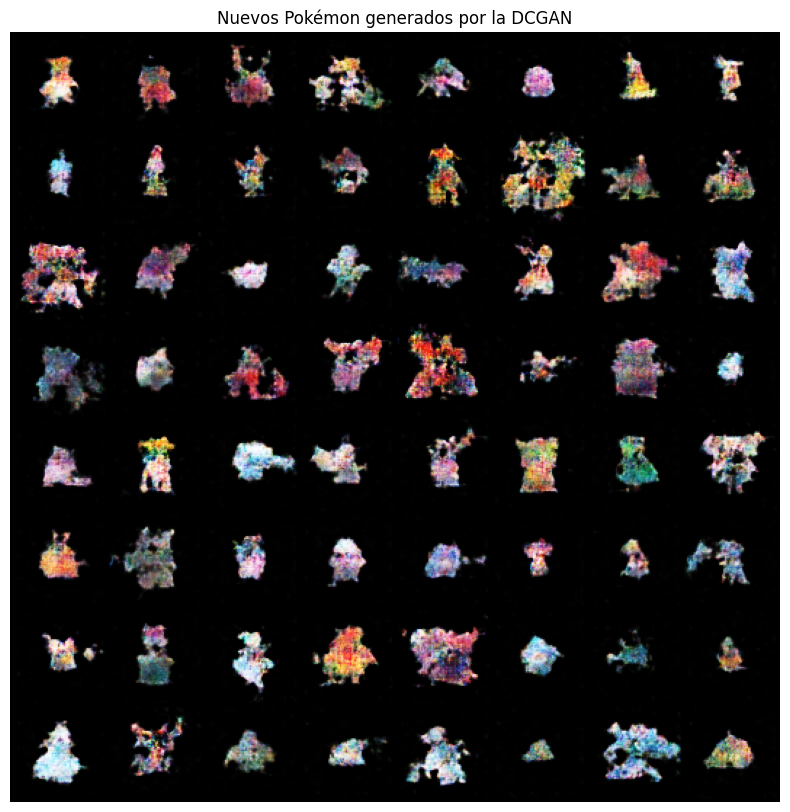

In [21]:
# Gráfica de Pérdidas
plt.figure(figsize=(10,5))
plt.title("Pérdidas del Generador y Discriminador (Entrenamiento Pokémon)")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("Iteraciones")
plt.ylabel("Pérdida")
plt.legend()
plt.show()

# Mostrar la última generación de imágenes
plt.figure(figsize=(10,10))
plt.axis("off")
plt.title("Nuevos Pokémon generados por la DCGAN")
plt.imshow(np.transpose(img_list[-1], (1,2,0)))
plt.show()